# First Task: (10 points) Read the two raster files and plot them.
- Read the 2022 and 2023 California CDL raster files.
- Plot the raster files.
- Use the provided `california_counties.gpkg` for drawing the shape of California and the counties in all plots.

### 1.1 Import Packages

**Operation:**
- 导入地理空间数据处理和可视化所需的所有库：`rasterio` 用于读取栅格图层数据，`geopandas` 用于读取和处理加州县级矢量的边界数据，`matplotlib` 用于绘图。
- 导入 `warnings` 忽略在坐标系转换中可能存在的无关警告信息。

In [4]:
# Imports for geospatial analysis and plotting
import rasterio
from rasterio.plot import show
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

### 1.2 Load Geographic Data and Raster Files, and Plot

**Operation:**
- 读取 2022 年与 2023 年的天地数据 (`.tif`) 以及加州各县边界数据 (`.gpkg`)。
- **重投影 (Reprojecting)**：确保 `.gpkg` 矢量数据的坐标系 (CRS) 能够匹配对应的 `.tif` 栅格数据，防止画图时位置错乱。
- **降采样 (Downsample)**：因为原始栅格图像（30m分辨率）非常大，直接绘图会极卡且可能导致内存溢出。所以这里采用了降采样的技术（长宽各缩小 10 倍，即采样率为 1/100）来大幅提升绘图效率，插值方法选择了针对分类数据最合适的 `nearest` 最近邻算法。
- **叠加绘制 (Overlay)**：利用 `matplotlib` 绘制这两个年份的分类地图，并将加州县级边界叠加在上方，同时将数据中的 `0` 值（代表背景）过滤掉（设为 `np.nan`），以便绘图看起来更整洁。

---

# Second Task: (15 points) Summarize the top 10 land uses.
- Summarize the top 10 land uses (by area) in California in each year.
- Rank from top 1 to top 10.
- Use the dictionary here (`cdl_dict.csv`). Ignore when Codes=0, which is just background.

### 2.1 Load Dictionary and Calculate Top 10 Land Uses

**Operation:**
- 加载土地类别字典（`cdl_dict.csv`），建立编码 (`Codes`) 与土地类别名称 (`Class_Names`) 的映射关系。
- 鉴于原版 `.tif` 栅格文件体积较大（接近 1GB），如果一次性将整个图像数组读入内存可能会因内存耗尽而宕机。因此采用了**分块读取计数 (Block/Window Processing)** 策略，利用 `rasterio` 遍历图像内部的各个物理分块，使用 `np.unique()` 配合 `return_counts=True` 逐步累加每个类别的像素个数 (Pixel Count)。
- 统计完成后，剔除 `Code=0` （背景值）的无效计数，因为题目要求忽略此项。
- 对每个年份的结果根据像素总数（代表相对面积）进行降序排序，选取排名前 10 的类别，最后以更为直观的 Pandas DataFrame 格式打印输出。

In [8]:
# Imports for dictionary and counting
import pandas as pd
import rasterio
import numpy as np
from pathlib import Path
from collections import Counter
from IPython.display import display

raw_dir = Path("../raw")
file_2022 = raw_dir / "2022_30m_cdls_ca.tif"
file_2023 = raw_dir / "2023_30m_cdls_ca.tif"

# Load the dictionary mapping
cdl_dict_path = raw_dir / "cdl_dict.csv"
cdl_dict_df = pd.read_csv(cdl_dict_path)
code_to_name = dict(zip(cdl_dict_df['Codes'], cdl_dict_df['Class_Names']))

# Helper function to compute top 10 safely without blowing up memory
def get_top_10_land_use(raster_path, code_mapping):
    counts = Counter()
    
    with rasterio.open(raster_path) as src:
        # Process the raster block by block to conserve RAM
        for window_id, window in src.block_windows(1):
            block_data = src.read(1, window=window)
            
            # Find unique pixel values and their frequency in the current block
            unique_vals, unique_counts = np.unique(block_data, return_counts=True)
            
            # Update the global counter
            for val, count in zip(unique_vals, unique_counts):
                counts[val] += count
                
    # Remove the background (Code = 0)
    if 0 in counts:
        del counts[0]
        
    # Extract the top 10 most frequent codes
    top_10 = counts.most_common(10)
    
    # Store results in a list of dictionaries for clean formatting
    results = []
    for rank, (code, pixel_count) in enumerate(top_10, start=1):
        name = code_mapping.get(code, f"Unknown Code ({code})")
        results.append({
            "Rank": rank,
            "Land Use": name,
            "Code": code,
            "Pixel Count": pixel_count
        })
        
    return pd.DataFrame(results)

# Calculate and display results for both years
print("Calculating top 10 land uses for 2022 ...\n")
top10_2022_df = get_top_10_land_use(file_2022, code_to_name)
print("Top 10 Land Uses in 2022:")
display(top10_2022_df)

print("\n--------------------------------------------------------------\n")

print("Calculating top 10 land uses for 2023 ...\n")
top10_2023_df = get_top_10_land_use(file_2023, code_to_name)
print("Top 10 Land Uses in 2023:")
display(top10_2023_df)

Calculating top 10 land uses for 2022 ...

Top 10 Land Uses in 2022:


,Rank,Land Use,Code,Pixel Count
0,1,Shrubland,152,197962979
1,2,Evergreen Forest,142,92009277
2,3,Grass/Pasture,176,49855726
3,4,Barren,131,22010391
4,5,Developed/Open Space,121,12140550
5,6,Developed/Med Intensity,123,9318914
6,7,Almonds,75,8354651
7,8,Developed/Low Intensity,122,7178483
8,9,Mixed Forest,143,6429294
9,10,Open Water,111,5871256



--------------------------------------------------------------

Calculating top 10 land uses for 2023 ...

Top 10 Land Uses in 2023:


,Rank,Land Use,Code,Pixel Count
0,1,Shrubland,152,197738671
1,2,Evergreen Forest,142,92034879
2,3,Grass/Pasture,176,49951311
3,4,Barren,131,21948319
4,5,Developed/Open Space,121,11978646
5,6,Developed/Med Intensity,123,9325097
6,7,Almonds,75,8424681
7,8,Developed/Low Intensity,122,7215885
8,9,Mixed Forest,143,6289996
9,10,Open Water,111,5853582


Each pixel in the CDL raster represents a $30m \times 30m$ area ($900 m^2$). Therefore, ranking by Pixel Count is strictly equivalent to ranking by physical area.

# Third Task: (20 points) Create and plot binary rasters for almonds and grapes.
- Create two rasters for each year:
  - 1 if pixel is almonds, 0 otherwise
  - 1 if pixel is grapes, 0 otherwise
- And then plot them. [Check the dictionary to have the Codes representing almonds and grapes. When plotting, you can downsample for speed.]

### 3.1 Extract Specific Crops and Plot

**Operation:**
- 根据 `cdl_dict.csv`，确定“杏仁 (Almonds)”的编号为 `75`，“葡萄 (Grapes)”的编号为 `69`。
- 构建辅助函数 `plot_binary_crop`，在读取数据并降采样（以防内存占满和绘图卡顿）后，使用条件判断 `data == crop_code` 生成二值数组（目标作物值为 1，其他值为 0）。
- 将背景区域中非 1 的值替换为 `NaN`（或者通过颜色映射调整背景透明），并与加州县级边界数据 `california_counties.gpkg` 叠加作图，使得可视化更加清晰有辨识度。
- 分别为 2022 年和 2023 年绘制 Almonds 和 Grapes 的分布图，合共生成四幅子图。

Plotting Almonds for 2022 and 2023...
Plotting Grapes for 2022 and 2023...


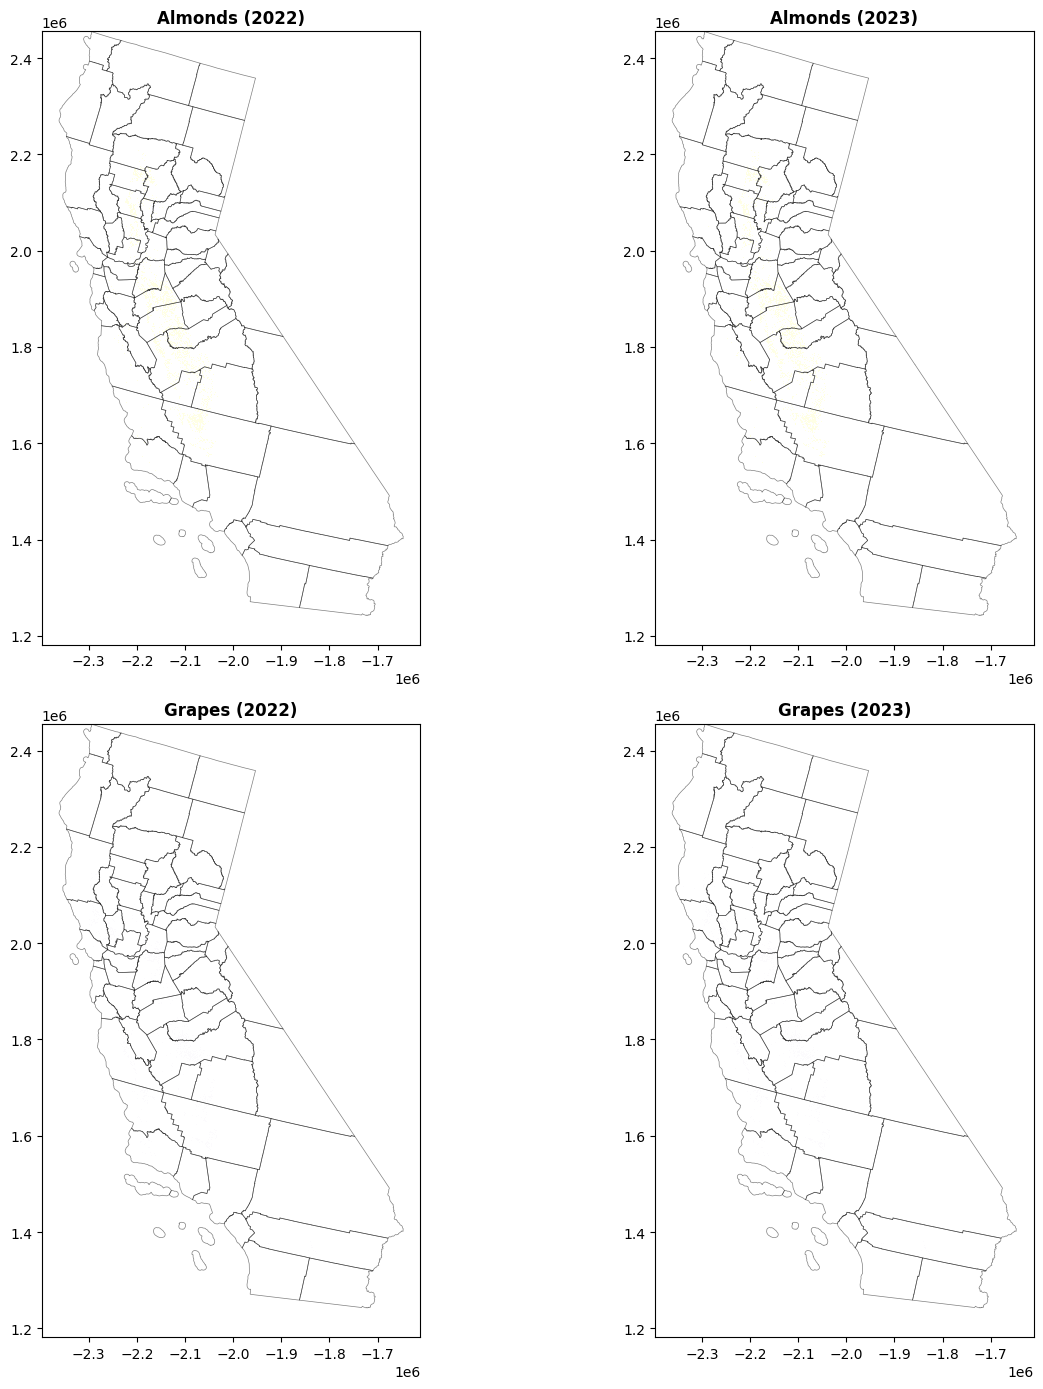

In [11]:
# Define the specific crop codes
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
import numpy as np
from pathlib import Path

raw_dir = Path("../raw")
file_2022 = raw_dir / "2022_30m_cdls_ca.tif"
file_2023 = raw_dir / "2023_30m_cdls_ca.tif"
counties_file = raw_dir / "california_counties.gpkg"

ALMONDS_CODE = 75
GRAPES_CODE = 69

# Load the vector data for California counties if not already loaded
counties_gdf = gpd.read_file(counties_file)

def plot_binary_crop(raster_path, ax, crop_code, title, color_map, downsample_factor=10):
    with rasterio.open(raster_path) as src:
        # Reproject counties boundaries to match the CRS
        counties_proj = counties_gdf.to_crs(src.crs)
        
        # Calculate new dimensions for downsampling
        new_height = int(src.height // downsample_factor)
        new_width = int(src.width // downsample_factor)
        
        # Read the first band with nearest neighbor resampling
        data = src.read(
            1,
            out_shape=(new_height, new_width),
            resampling=rasterio.enums.Resampling.nearest
        )
        
        # Create binary array: 1 if pixel matches the crop code, else 0
        binary_data = (data == crop_code).astype(int)
        
        # Mask out 0s (non-target pixels) by replacing with NaN to make background transparent
        masked_data = np.where(binary_data == 0, np.nan, binary_data)
        
        # Update transform
        transform = src.transform * src.transform.scale(
            (src.width / new_width),
            (src.height / new_height)
        )
        
        # Plot the raster using the specified colormap
        show(masked_data, transform=transform, ax=ax, title=title, cmap=color_map, interpolation='none')
        counties_proj.boundary.plot(ax=ax, color='black', linewidth=0.5, alpha=0.5)

# Set up a 2x2 grid for plotting
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

# Plot Almonds for 2022 and 2023 (Using a localized color, e.g., 'copper' or 'YlOrBr')
print("Plotting Almonds for 2022 and 2023...")
plot_binary_crop(file_2022, axes[0, 0], ALMONDS_CODE, "Almonds (2022)", 'YlOrBr', downsample_factor=10)
plot_binary_crop(file_2023, axes[0, 1], ALMONDS_CODE, "Almonds (2023)", 'YlOrBr', downsample_factor=10)

# Plot Grapes for 2022 and 2023 (Using a localized color, e.g., 'Purples')
print("Plotting Grapes for 2022 and 2023...")
plot_binary_crop(file_2022, axes[1, 0], GRAPES_CODE, "Grapes (2022)", 'Purples', downsample_factor=10)
plot_binary_crop(file_2023, axes[1, 1], GRAPES_CODE, "Grapes (2023)", 'Purples', downsample_factor=10)

plt.tight_layout()
plt.show()

---

# Fourth Task: (10 points) Describe crop rotation.
- Describe the degree of crop rotation (almonds and grapes only) between 2022 and 2023.
- [Use count of pixels.]

### 4.1 Count Crop Rotation Transitions

**Operation:**
- 同时打开 2022 年和 2023 年两份 `.tif` 数据，依然应用 **Block/Window Processing（分块处理）** 技术，遍历图像对应坐标的小块内存，防止 OOM 溢出。
- 设置针对性过滤：因为我们只关心杏仁(75)与葡萄(69)的相关转变，所以通过逻辑判断和掩码 `((data_2022 == ALMONDS_CODE) | (data_2022 == GRAPES_CODE))` 来定位分析关注的像元。
- 计算并记录各个转换状态的像元数量（即只统计：杏仁 $\rightarrow$ 杏仁，葡萄 $\rightarrow$ 葡萄，杏仁 $\rightarrow$ 葡萄，以及 葡萄 $\rightarrow$ 杏仁）。
- 最后输出直观的统计分析结果，来回答两者之间的土地轮作程度。

In [12]:
# Initialize the counters for specific state transitions
almonds_to_almonds = 0
grapes_to_grapes = 0
almonds_to_grapes = 0
grapes_to_almonds = 0

print("Calculating crop rotation from 2022 to 2023 (Block processing)...")

# Open both files simultaneously and process window by window
with rasterio.open(file_2022) as src_2022, rasterio.open(file_2023) as src_2023:
    for window_id, window in src_2022.block_windows(1):
        # Read the blocks
        data_2022 = src_2022.read(1, window=window)
        data_2023 = src_2023.read(1, window=window)
        
        # Almonds -> Almonds
        almonds_to_almonds += np.sum((data_2022 == ALMONDS_CODE) & (data_2023 == ALMONDS_CODE))
        
        # Grapes -> Grapes
        grapes_to_grapes += np.sum((data_2022 == GRAPES_CODE) & (data_2023 == GRAPES_CODE))
        
        # Almonds -> Grapes
        almonds_to_grapes += np.sum((data_2022 == ALMONDS_CODE) & (data_2023 == GRAPES_CODE))
        
        # Grapes -> Almonds
        grapes_to_almonds += np.sum((data_2022 == GRAPES_CODE) & (data_2023 == ALMONDS_CODE))

# Presenting the findings
print("\nCrop Rotation Results (in Pixel Count):")
print(f"Almonds stayed Almonds: {almonds_to_almonds}")
print(f"Grapes stayed Grapes:   {grapes_to_grapes}")
print(f"Almonds changed to Grapes: {almonds_to_grapes}")
print(f"Grapes changed to Almonds: {grapes_to_almonds}")

# Describe the degree
total_almonds_2022 = almonds_to_almonds + almonds_to_grapes
total_grapes_2022 = grapes_to_grapes + grapes_to_almonds

print("\n--- Description ---")
print("These numbers indicate that the degree of crop rotation specifically between almonds and grapes is extremely low.")
if total_almonds_2022 > 0:
    print(f"Only {(almonds_to_grapes/total_almonds_2022)*100:.4f}% of the Almonds in 2022 were rotated to Grapes in 2023.")
if total_grapes_2022 > 0:
    print(f"Only {(grapes_to_almonds/total_grapes_2022)*100:.4f}% of the Grapes in 2022 were rotated to Almonds in 2023.")
print("This makes sense because both almonds and grapes are permanent/perennial crops (orchards and vineyards). Once planted, growers typically keep them for decades rather than rotating them yearly.")

Calculating crop rotation from 2022 to 2023 (Block processing)...

Crop Rotation Results (in Pixel Count):
Almonds stayed Almonds: 7707502
Grapes stayed Grapes:   3640676
Almonds changed to Grapes: 28188
Grapes changed to Almonds: 96896

--- Description ---
These numbers indicate that the degree of crop rotation specifically between almonds and grapes is extremely low.
Only 0.3644% of the Almonds in 2022 were rotated to Grapes in 2023.
Only 2.5925% of the Grapes in 2022 were rotated to Almonds in 2023.
This makes sense because both almonds and grapes are permanent/perennial crops (orchards and vineyards). Once planted, growers typically keep them for decades rather than rotating them yearly.


| 2022 \ 2023 | Almonds              | Grapes               |
| ----------- | -------------------- | -------------------- |
| **Almonds** | 7,707,502 *(Stayed)* | 28,188 *(Rotated)*   |
| **Grapes**  | 96896 *(Rotated)*   | 3,640,676 *(Stayed)* |

---

# Fifth & Sixth Task: (25 points) Create and visualize state transition raster.
- (15 points) Create a raster using the CDL layers where each pixel is labeled:
  - 1 = almonds stayed almonds
  - 2 = grapes stayed grapes
  - 3 = almonds changed to grapes
  - 4 = grapes changed to almonds
  - 0 = any other case
- (10 points) Visualize the raster data you created. Label the legend clearly. Ignore “0 = any other case” to make the graph background look cleaner.

### 5.1 & 6.1 Identify crop changes and plot with clearly labeled legends

**Operation:**
- 同时加载 2022 年与 2023 年图层进行**降采样 (Downsample)** 操作。在降采样过程中，为了能够精确地生成状态逻辑地图（而不在后续绘图中发生数组失真），必须统一在这一个阶段构造出包含 `0, 1, 2, 3, 4` 五种状态的“变换数据”。
- 我们直接在内存中建立一个全为 `0` 的 `transition_data` 数组记录状态：
  - 如果数据在2022是杏仁并且在2023也是杏仁，设置为 `1`。
  - ...后续依据规则同样设置 `2, 3, 4` 状态。
- **可视化部分 (Sixth Task)**：利用 `matplotlib.colors` 构建针对上述1、2、3、4的自定义的颜色列表 (比如使用比较有反差的红、紫、蓝、绿) ，并且通过将 `0`（背景与无关变动）设定为 `NaN` 使得最终生成的图更干净。最后，在画布旁边附加对应的自定义图例。

Generating and plotting transition raster. Please wait...


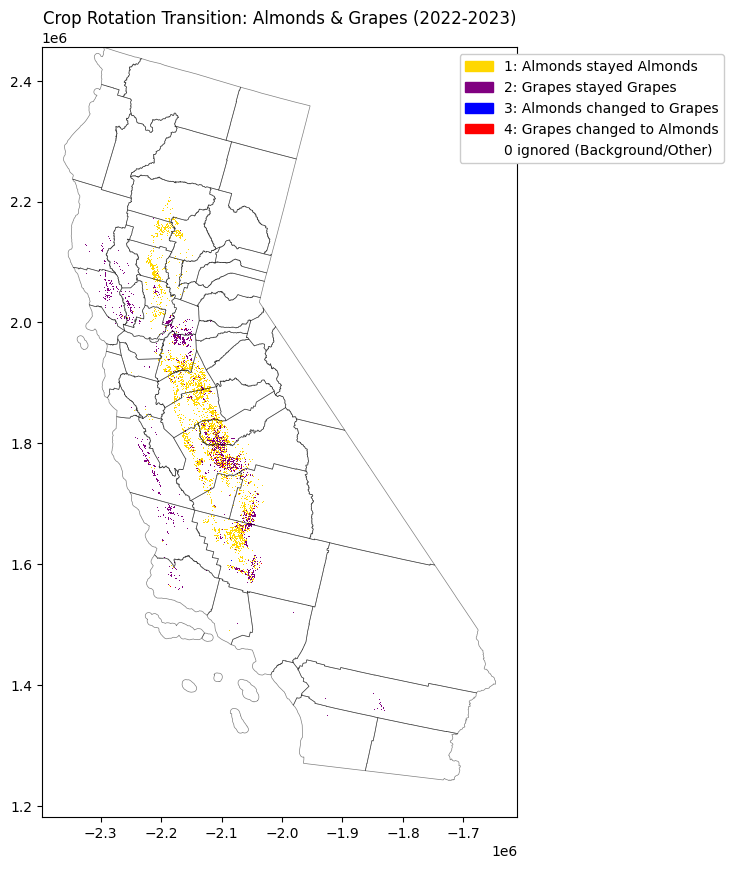

In [13]:
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches

def create_and_plot_transition_raster(raster_2022, raster_2023, ax, downsample_factor=10):
    with rasterio.open(raster_2022) as src_22, rasterio.open(raster_2023) as src_23:
        # Check alignment
        if src_22.crs != src_23.crs or src_22.shape != src_23.shape:
            raise ValueError("The two rasters do not match in shape or CRS.")
            
        counties_proj = counties_gdf.to_crs(src_22.crs)
        
        # Calculate new downsampled shape
        new_height = int(src_22.height // downsample_factor)
        new_width = int(src_22.width // downsample_factor)
        
        # Read both years downsampled using 'nearest' exactly aligning their pixels
        data_22 = src_22.read(1, out_shape=(new_height, new_width), resampling=rasterio.enums.Resampling.nearest)
        data_23 = src_23.read(1, out_shape=(new_height, new_width), resampling=rasterio.enums.Resampling.nearest)
        
        # Initialize the transition array with 0 (any other case)
        transition_data = np.zeros_like(data_22, dtype=float)
        
        # 1 = almonds stayed almonds
        transition_data[(data_22 == ALMONDS_CODE) & (data_23 == ALMONDS_CODE)] = 1
        
        # 2 = grapes stayed grapes
        transition_data[(data_22 == GRAPES_CODE) & (data_23 == GRAPES_CODE)] = 2
        
        # 3 = almonds changed to grapes
        transition_data[(data_22 == ALMONDS_CODE) & (data_23 == GRAPES_CODE)] = 3
        
        # 4 = grapes changed to almonds
        transition_data[(data_22 == GRAPES_CODE) & (data_23 == ALMONDS_CODE)] = 4
        
        # Ignore "0 = any other case" for plotting (set to NaN to make it transparent)
        transition_masked = np.where(transition_data == 0, np.nan, transition_data)
        
        # Define transform
        transform = src_22.transform * src_22.transform.scale(
            (src_22.width / new_width),
            (src_22.height / new_height)
        )
        
        # Define Custom Colormap for the 4 states
        # 1: Gold (Almonds->Almonds), 2: Purple (Grapes->Grapes)
        # 3: Blue (Almonds->Grapes transition), 4: Red (Grapes->Almonds transition)
        cmap = mcolors.ListedColormap(['gold', 'purple', 'blue', 'red'])
        
        # Map values 1, 2, 3, 4 linearly to the custom colormap
        bounds = [0.5, 1.5, 2.5, 3.5, 4.5]
        norm = mcolors.BoundaryNorm(bounds, cmap.N)
        
        # Plot
        show(transition_masked, transform=transform, ax=ax, cmap=cmap, norm=norm, interpolation='none')
        counties_proj.boundary.plot(ax=ax, color='black', linewidth=0.5, alpha=0.5)

# Execute the combined operations
fig, ax = plt.subplots(figsize=(10, 10))
print("Generating and plotting transition raster. Please wait...")
create_and_plot_transition_raster(file_2022, file_2023, ax, downsample_factor=10)

ax.set_title("Crop Rotation Transition: Almonds & Grapes (2022-2023)")

# Manually create the legend
legend_elements = [
    mpatches.Patch(color='gold', label='1: Almonds stayed Almonds'),
    mpatches.Patch(color='purple', label='2: Grapes stayed Grapes'),
    mpatches.Patch(color='blue', label='3: Almonds changed to Grapes'),
    mpatches.Patch(color='red', label='4: Grapes changed to Almonds'),
    mpatches.Patch(color='none', label='0 ignored (Background/Other)')
]
ax.legend(handles=legend_elements, loc='upper right', framealpha=1, bbox_to_anchor=(1.45, 1))

plt.show()

---

# Seventh Task: (10 points) Answer Client Question.
- Describe how you might answer this question using the CDL layer, specifically:
  - What data sources you would need in addition to the raster you just created.
  - How you would manipulate the data.
  - What statistics you would calculate or model you would run on this data.
  - How you might present your findings. [This is not a coding question.]

### 7.1 Analytical Approach

**Client Question:** "What are the crop yield advantages of crop rotation as compared to monocropping in California?"

**Response / Approach:**

1. **Additional Data Sources Needed:**  
   - **Crop Yield Data:** I would need localized historical or annual crop yield data (e.g., from the USDA NASS or local county agricultural commissioners) that can be geographically linked to our CDL pixel coordinates or at least to county/field-level geographies.  
   - **Weather/Climate Data:** Metrics such as precipitation, temperature, and drought indices (e.g., PRISM climate data) to control for environmental variations across regions.  
   - **Soil Data:** Data regarding soil quality/types (e.g., from SSURGO or USDA NRCS) since inherent land quality greatly influences yields.

2. **Data Manipulation / Processing:**  
   - First, I would extend our CDL classification over a longer time horizon (e.g., 5-10 years) rather than just two years, as determining true "rotation" vs "monocropping" requires observing multiple growing cycles.
   - Next, I would create a categorical identifier for each geographic unit (e.g., field or pixel cluster): tagging those strictly as "Monocropped" (same crop code > 80% of the time) and others as "Rotated".
   - Finally, perform a spatial join to merge the crop classification with the local yield data, soil data, and weather data at the corresponding geographic level.

3. **Statistics and Modeling:**  
   - **Descriptive Statistics:** Calculate the average yield and variance for monocropped fields versus rotated fields for the current year.
   - **Econometric Modeling:** Run a multivariate regression model (e.g., Fixed Effects Panel Regression). The dependent variable would be "Crop Yield", while the main independent variable of interest is a dummy variable indicating "Crop Rotation".  
   - **Controls:** I would control for precipitation, temperature, soil quality, and apply fixed effects for the county and year to isolate the true effect of rotation.

4. **Presenting Findings:**  
   - **Visualizations:** Create bar charts with error bars comparing the average yields between the two practices. Additionally, a spatial map showing regions where crop rotation yielded the most significant positive impact.
   - **Non-Technical Summary:** Provide a summary table highlighting the percentage yield increase (the coefficient from our model) resulting from rotation, accompanied by brief bullet points translating the statistical significance into actionable business or policy recommendations for the client.

---

# Eighth Task: (10 points) Challenges in answering the question.
- What factors would make it difficult to accurately answer the question?
- List three and explain why they might make answering the question difficult.
- [This is not a coding question.]

### 8.1 Factors Making Accuracy Difficult

Here are three factors that make accurately determining the advantages of crop rotation over monocropping challenging:

1. **Self-Selection Bias (Endogeneity):**  
   *Explanation:* Farmers do not choose their crop patterns randomly. A farmer with poorer quality land or limited water access might be forced into monocropping (or alternatively, forced to rotate). If rotation appears to have higher yields, it could simply be because smarter, more resourceful, or wealthier farmers (who already have better overall yields due to fertilizer usage or advanced technology) are the ones practicing rotation. This unobserved farmer heterogeneity makes it hard to isolate the true causal effect of rotation purely from observational data.

2. **Spatial and Temporal Mismatch (Data Resolution Issues):**  
   *Explanation:* CDL raster data comes in a 30m x 30m pixel resolution, which rarely aligns perfectly exactly with specific farm boundaries. Moreover, yield data is often only publicly available at aggregate levels like the county or district level—not at the pixel or individual field level. This ecological fallacy means we lose variance, and inferring field-level effects (rotation) from aggregated output (county yield) leads to noisy, potentially biased estimates.

3. **Confounding Environmental Shocks:**  
   *Explanation:* Agriculture is highly vulnerable to external shocks such as localized droughts, wildfires, pests, or diseases (which frequently happen in California). If a pest wipes out a monocropped area on a specific year, the model might wrongly attribute the low yield entirely to "monocropping" rather than the exogenous shock. Unless we have fine-grained, localized meteorological and disaster datasets to perfectly control for these micro-variations, the isolated effect of crop rotation will be distorted.